## Phase 2 Project - Group 5

### Business Understanding
#### Overview/Background
- We are a new content creation company that want to set up a movie studio to start making original content in the form of film (movies, documentaries,etc) 

- Our decision is spurred by observing trends in big media conglomerates diversifying their offerings from public broadcasting (news, documentaries) into original content in the form of long and short form films. 

#### Challenges
- We currently have a gap in our understanding of the current movie landscape from the demand side and want our analysis to answer the simple question: what kind of movies are most people watching? 

#### Proposed Solution
- To answer this question, we will carry out **a comprehensive market analysis**, using data sourced from popular movie rating databases as well as revenue data describing the financial performance of movies.

- Our core business metric would be **gross movie revenue** across movie genres in both domestic and foreign markets, i.e., what kind of movies have made the most money? 

- This analysis will not only guide our content generation strategy but also our business strategy as to which market to focus on.


#### Key Objectives
- Our analysis will be guided by the following key business objectives:

    1. To determine the most popular movie genres based on movie ratings and revenues

    2. To determine the best movie directors based on movie revenues
    
    3. To determine the most profitable movie markets based on movie revenues


## Data Understanding

#### Film Titles & Genres:
- The dataset contains a variety of film titles along with their genres (e.g., Action, Drama, Comedy).

- Certain genres may consistently perform better at the box office.

#### Box Office Performance:
- Box Office Mojo provides domestic and worldwide gross earnings.

- This financial data helps identify the types of movies that bring the highest returns.


#### Ratings & Viewer Feedback:
- IMDB and Rotten Tomatoes offer user ratings, critic scores, and audience reception.

- Highly-rated films may indicate preferred content types or production quality.


#### Release Year & Trends:
- Films are tagged with their release year, allowing for trend analysis over time.

- Helps determine if recent years favor specific film styles or formats.


#### Multi-Source Data Integration:
- By combining IMDB (content), Box Office Mojo (revenue), and Rotten Tomatoes (ratings), we can form a well-rounded view of what makes a film both critically and financially successful.



## Data Preparation and Analysis

#### Importing Relevant Libraries

- We start by importing the following libraries: **NumPy**, **Pandas**, **SQLite**, **Matplotlib** and **Seaborn**

In [1]:
# importing necessary libraries
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

- We then open up a connection to the SQLite database and store the connection in a variable called `conn`. Afterwards, we initialize a SQLite cursor object with the variable name `cursor`.

In [2]:
# read our sqlite database and create a variable df to hold the database
df = "./zippedData/im.db/im.db"

# Open up a connection
conn = sqlite3.connect(df)

# Initialize a cursor
cursor = conn.cursor()

### Data Ingest
- We are going to extract data from the following databases:
    - The IMBD database
    - Movie Budgets (csv)


#### Extracting tables from SQL database 

- We will use `pd.read_sql` to output the tables in the SQLite database via SQL queries 

- When writing our queries, we will use the table names as listed below:

In [3]:

table_names = """SELECT name 
                      AS 'Table Names' 
                      FROM sqlite_master 
                      WHERE type='table';"""

pd.read_sql(table_names, conn)

,Table Names
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


- We define the SQL queries we will use to extract the relevant tables from our dataset and then apply `pd.read_sql` to output our tables as dataframes

- Our tables of interest include: `movie_basics`, `movie_akas`, `movie_ratings`, `directors` and `persons`


In [4]:
movie_basics_query = """SELECT * FROM movie_basics;"""
movie_basics_df = pd.read_sql(movie_basics_query, conn)

movie_ratings_query = """SELECT * FROM movie_ratings;"""
movie_ratings_df = pd.read_sql(movie_ratings_query, conn)

movie_akas_query = """SELECT * FROM movie_akas;""" 
movie_akas_df = pd.read_sql(movie_akas_query, conn)

directors_query = """SELECT * FROM directors;"""
directors_df = pd.read_sql(directors_query, conn)

persons_query = """SELECT * FROM persons;"""
persons_df = pd.read_sql(persons_query, conn)

- The dataset on movie revenue exists as a `csv` file so we extract it and save it as Dataframe as well:

In [5]:
movie_budgets_df = pd.read_csv("./zippedData/tn.movie_budgets.csv.gz")

movie_budgets_df.rename(columns={"movie": "title"}, inplace=True)


#### Inspecting our Dataframes

- We quickly inspect the resulting dataframes:

In [6]:
movie_basics_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [7]:
movie_ratings_df.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [8]:
movie_akas_df.head()

,movie_id,ordering,title,region,language,types,attributes,is_original_title
0,tt0369610,10,Джурасик свят,BG,bg,None,None,0.0
1,tt0369610,11,Jurashikku warudo,JP,None,imdbDisplay,None,0.0
2,tt0369610,12,Jurassic World: O Mundo dos Dinossauros,BR,None,imdbDisplay,None,0.0
3,tt0369610,13,O Mundo dos Dinossauros,BR,None,None,short title,0.0
4,tt0369610,14,Jurassic World,FR,None,imdbDisplay,None,0.0


In [9]:
movie_budgets_df.head()

,id,release_date,title,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [10]:
directors_df.head()

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502


In [11]:
persons_df.head()

,person_id,primary_name,birth_year,death_year,primary_profession
0,nm0061671,Mary Ellen Bauder,NaN,NaN,"miscellaneous,production_manager,producer"
1,nm0061865,Joseph Bauer,NaN,NaN,"composer,music_department,sound_department"
2,nm0062070,Bruce Baum,NaN,NaN,"miscellaneous,actor,writer"
3,nm0062195,Axel Baumann,NaN,NaN,"camera_department,cinematographer,art_department"
4,nm0062798,Pete Baxter,NaN,NaN,"production_designer,art_department,set_decorator"


### Data Cleaning
- We shall identify columns or rows in the tables with missing or duplicate values.

- Then we either fill in missing values or remove records that are too incomplete or records that are duplicated.

##### Check for missing values

In [12]:
# Checking all the tables for null values
print("-" * 60)
print("Movie Basics Null Values:", '\n')
print(movie_basics_df.isnull().sum())
print("-" * 60)
print("Movie Ratings Null Values:", '\n') 
print(movie_ratings_df.isnull().sum())
print("-" * 60)
print("Movie Akas Null Values:", '\n')
print(movie_akas_df.isnull().sum())
print("-" * 60)
print("Movie Budgets Null Values:", '\n')
print(movie_budgets_df.isnull().sum())
print("-" * 60)
print("Directors Null Values:", '\n')
print(directors_df.isnull().sum())
print("-" * 60)
print("Persons Null Values:", '\n')
print(persons_df.isnull().sum())
print("-" * 60)

------------------------------------------------------------
Movie Basics Null Values: 

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64
------------------------------------------------------------
Movie Ratings Null Values: 

movie_id         0
averagerating    0
numvotes         0
dtype: int64
------------------------------------------------------------
Movie Akas Null Values: 

movie_id                  0
ordering                  0
title                     0
region                53293
language             289988
types                163256
attributes           316778
is_original_title        25
dtype: int64
------------------------------------------------------------
Movie Budgets Null Values: 

id                   0
release_date         0
title                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64
-----------------------

##### Handle the missing values
- We do this by either dropping the missing values or filling the columns with 'unknown'

In [13]:
# Handling missing values

# Drop columns with more than 50% missing values in movie_akas_df
movie_akas_df = movie_akas_df.drop(columns=['language', 'attributes', 'types'])

# Drop rows with missing runtime_minutes in movie_basics_df
movie_basics_df = movie_basics_df.dropna(subset=['runtime_minutes'])


# Fill missing values in movie_akas_df
movie_akas_df['region'] = movie_akas_df['region'].fillna('Unknown')
movie_akas_df['is_original_title'] = movie_akas_df['is_original_title'].fillna(0)

# Fill missing values in persons_df
persons_df['birth_year'] = persons_df['birth_year'].fillna(0)
persons_df['death_year'] = persons_df['death_year'].fillna(0)
persons_df['primary_profession'] = persons_df['primary_profession'].fillna('Unknown')




- Recheck the updated dataframes to verify our changes:

In [14]:
# Print the updated dataframes to verify changes
print("-" * 60)
print("Updated movie_basics_df:",'\n')
print(movie_basics_df.isnull().sum())
print("-" * 60)
print("Updated movie_ratings_df:",'\n')
print(movie_ratings_df.isnull().sum())
print("-" * 60)
print("Updated movie_budgets_df:", '\n')
print(movie_budgets_df.isnull().sum())
print("-" * 60)
print("Updated movie_akas_df:", '\n')
print(movie_akas_df.isnull().sum())
print("-" * 60)
print("Updated directors_df:", '\n')
print(directors_df.isnull().sum())
print("-" * 60)
print("Updated persons_df:", '\n')
print(persons_df.isnull().sum())
print("-" * 60)


------------------------------------------------------------
Updated movie_basics_df: 

movie_id              0
primary_title         0
original_title        4
start_year            0
runtime_minutes       0
genres             2172
dtype: int64
------------------------------------------------------------
Updated movie_ratings_df: 

movie_id         0
averagerating    0
numvotes         0
dtype: int64
------------------------------------------------------------
Updated movie_budgets_df: 

id                   0
release_date         0
title                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64
------------------------------------------------------------
Updated movie_akas_df: 

movie_id             0
ordering             0
title                0
region               0
is_original_title    0
dtype: int64
------------------------------------------------------------
Updated directors_df: 

movie_id     0
person_id    0
dtype: int64
--------------

#### Handling Duplicates

- Remove duplicates in case any exist:

In [15]:
# Remove duplicates
movie_basics_df = movie_basics_df.drop_duplicates()
movie_ratings_df = movie_ratings_df.drop_duplicates()
movie_akas_df = movie_akas_df.drop_duplicates()
movie_budgets_df = movie_budgets_df.drop_duplicates()
directors_df = directors_df.drop_duplicates()
persons_df = persons_df.drop_duplicates()


#### Data Formatting

In [16]:
movie_budgets_df.head()

,id,release_date,title,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [17]:
movie_budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   title              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 316.2+ KB


In [18]:
# Convert data types
#movie_budgets_df['domestic_gross'] = movie_budgets_df['domestic_gross'].str.replace('[\$,]', '', regex=True).astype(float)
#movie_budgets_df['worldwide_gross'] = movie_budgets_df['worldwide_gross'].str.replace('[\$,]', '', regex=True).astype(float)
#movie_budgets_df['production_budget'] = movie_budgets_df['production_budget'].str.replace('[\$,]', '', regex=True).astype(float)
movie_budgets_df['release_date'] = pd.to_datetime(movie_budgets_df['release_date'], format="%b %d, %Y")


In [19]:
movie_budgets_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   title              5782 non-null   object        
 3   production_budget  5782 non-null   object        
 4   domestic_gross     5782 non-null   object        
 5   worldwide_gross    5782 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 316.2+ KB


### Save Cleaned Tables
In the cell below we have saved our cleaned dataframe into csv files for future reference.It is an optional step.

In [20]:
# Save cleaned dataframes to CSV files
# movie_basics_df.to_csv('cleaned_movie_basics.csv', index=False)
# movie_ratings_df.to_csv('cleaned_movie_ratings.csv', index=False)
# movie_akas_df.to_csv('cleaned_movie_akas.csv', index=False)
# movie_budgets_df.to_csv('cleaned_movie_budgets.csv', index=False)
# directors_df.to_csv('cleaned_directors.csv', index=False)
# persons_df.to_csv('cleaned_persons.csv', index=False)


### Data Merging
- We will combine our 6 resulting dataframes in this fashion:

    1) Merge `movies_basics_df` with `movie_ratings` on `movie_id` and save as `movies_consolidated_df`

    2) Merge resulting `movies_consolidated_df` with `movie_akas_df` on `movie_id` and save as `movies_consolidated_df`

    3) Merge resulting `movies_consolidated_df` with `directors_df` on `movie_id` and save as `movies_consolidated_df`

    4) Merge resulting `movies_consolidated_df` with `persons_df` on `person_id` and save as `movies_consolidated_df`

    5) Merge resulting `movies_consolidated_df` with `movie_budgets_df` on `title` and save as `movies_consolidated_df`


In [21]:
# Merge movie_basics_df with movie_ratings_df on movie_id
movies_consolidated_df = pd.merge(movie_basics_df, movie_ratings_df, on='movie_id', how='left')

# Merge the result with movie_akas_df on movie_id
movies_consolidated_df = pd.merge(movies_consolidated_df, movie_akas_df, on='movie_id', how='left')

# Merge the result with directors_df on movie_id
movies_consolidated_df = pd.merge(movies_consolidated_df, directors_df, on='movie_id', how='left')

# Merge the result with persons_df on person_id
movies_consolidated_df = pd.merge(movies_consolidated_df, persons_df, on='person_id', how='left')

# Rename key columns in movies_consolidated_df
movies_consolidated_df.rename(columns={'primary_title': 'title'}, inplace=True) # Rename primary_title to title
movies_consolidated_df.rename(columns={'start_year': 'release_year'}, inplace=True) # Rename start_year to release_year

# Create a new column in movie_budgets_df for the release year
movie_budgets_df['release_year'] = movie_budgets_df['release_date'].dt.year

# Drop any duplicated columns in movies_consolidated_df
movies_consolidated_df = movies_consolidated_df.loc[:,~movies_consolidated_df.columns.duplicated()]

# Merge movies_consolidated_df with movie_budgets_df on title and release_year and create a new dataframe
movies_consolidated_df_2 = pd.merge(movies_consolidated_df, movie_budgets_df, on=['title','release_year'], how='left')

movies_consolidated_df_2.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 362408 entries, 0 to 362407
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   movie_id            362408 non-null  object        
 1   title               362408 non-null  object        
 2   original_title      362395 non-null  object        
 3   release_year        362408 non-null  int64         
 4   runtime_minutes     362408 non-null  float64       
 5   genres              358926 non-null  object        
 6   averagerating       292472 non-null  float64       
 7   numvotes            292472 non-null  float64       
 8   ordering            347086 non-null  float64       
 9   region              347086 non-null  object        
 10  is_original_title   347086 non-null  float64       
 11  person_id           359636 non-null  object        
 12  primary_name        359630 non-null  object        
 13  birth_year          359630 no

##### Conduct further cleaning on the consolidated Dataframes

- `movies_consolidated_df` only contains movie data while `movies_consolidated_df_2` contains movie data + revenue data

In [22]:
# Drop duplicate rows based on movie_id and person_id
movies_consolidated_df = movies_consolidated_df.drop_duplicates(subset=['movie_id'])
movies_consolidated_df_2 = movies_consolidated_df_2.drop_duplicates(subset=['movie_id'])

# Drop rows with missing values in the merged dataframe
movies_consolidated_df = movies_consolidated_df.dropna(subset=['averagerating','numvotes'])
movies_consolidated_df_2 = movies_consolidated_df_2.dropna(subset=['averagerating','numvotes','domestic_gross', 'worldwide_gross',])

# Change the data type of the 'release_date' column to datetime
movies_consolidated_df_2['release_date'] = pd.to_datetime(movies_consolidated_df_2['release_date'], format="%Y-%m-%d")

# Change the data type of 'worldwide_gross'/'domestic_gross' to float
movies_consolidated_df_2['worldwide_gross'] = movies_consolidated_df_2['worldwide_gross'].replace('[\$,]', '', regex=True).astype(float)
movies_consolidated_df_2['domestic_gross'] = movies_consolidated_df_2['domestic_gross'].replace('[\$,]', '', regex=True).astype(float)
movies_consolidated_df_2['production_budget'] = movies_consolidated_df_2['production_budget'].replace('[\$,]', '', regex=True).astype(float)

# Drop unnecessary columns
irrelevant_columns = ['person_id','ordering','original_title','birth_year','death_year', 'is_original_title']
movies_consolidated_df = movies_consolidated_df.drop(columns=irrelevant_columns)
movies_consolidated_df_2 = movies_consolidated_df_2.drop(columns=irrelevant_columns)

# Rename columns for clarity
movies_consolidated_df.rename(columns={'primary_name': 'director_name', 'primary_profession': 'director_profession'}, inplace=True)
movies_consolidated_df_2.rename(columns={'primary_name': 'director_name', 'primary_profession': 'director_profession'}, inplace=True)

# Fill missing values in the remaining columns
movies_consolidated_df['director_name'] = movies_consolidated_df['director_name'].fillna('Unknown')
movies_consolidated_df['director_profession'] = movies_consolidated_df['director_profession'].fillna('Unknown')

movies_consolidated_df_2['director_name'] = movies_consolidated_df['director_name'].fillna('Unknown')
movies_consolidated_df_2['director_profession'] = movies_consolidated_df['director_profession'].fillna('Unknown')

#Save the consolidated dataframe to a CSV file
movies_consolidated_df.to_csv('movies_consolidated_2.csv', index=False)
movies_consolidated_df_2.to_csv('movies_consolidated_withRevenue.csv', index=False)

# Display the first few rows of the consolidated dataframe
movies_consolidated_df_2.head().reset_index(drop=True)


,movie_id,title,release_year,runtime_minutes,genres,averagerating,numvotes,region,director_name,director_profession,id,release_date,production_budget,domestic_gross,worldwide_gross
0,tt0249516,Foodfight!,2012,91.0,"Action,Animation,Comedy",1.9,8248.0,FI,Lawrence Kasanoff,"producer,writer,director",26.0,2012-12-31,45000000.0,0.0,7.370600e+04
1,tt0359950,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",7.3,275300.0,CZ,Ben Stiller,"producer,actor,director",37.0,2013-12-25,91000000.0,58236838.0,1.878612e+08
2,tt0365907,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",6.5,105116.0,RU,Scott Frank,"writer,producer,director",67.0,2014-09-19,28000000.0,26017685.0,6.210859e+07
3,tt0369610,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",7.0,539338.0,BG,Colin Trevorrow,"writer,producer,director",34.0,2015-06-12,215000000.0,652270625.0,1.648855e+09
4,tt0376136,The Rum Diary,2011,119.0,"Comedy,Drama",6.2,94787.0,BR,Bruce Robinson,"actor,writer,director",16.0,2011-10-28,45000000.0,13109815.0,2.154473e+07


In [23]:
## Create a color palette like Microsoft Office 'Red Orange' theme
red_orange_palette = [
    "#C00000",  # Dark Red
    "#E46C0A",  # Orange-ish
    "#FF9900",  # Vivid Orange
    "#FFC000",  # Yellow-Orange
    "#F79646",  # Lighter Orange
    "#FF6600",  # Bright Red-Orange
    "#B85450"   # Muted Brick
]


### Exploratory Data Analysis(EDA)

#### Distribution of movie ratings
- The 'distribution of the movie ratings' refers to how different movie ratings were given to a movie.
- In the cell below we are going to plot a histogram so as to determine our distribution.

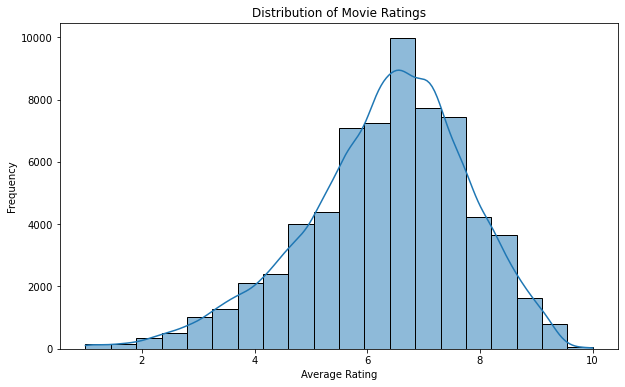

In [24]:
# Plotting the distribution of movie ratings
plt.figure(figsize=(10, 6))
sns.histplot(movies_consolidated_df['averagerating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()

#### Objective 1: Find the Highest Grossing Movie Genres

In [25]:
# Create a new dataframe with Genres and Gross Revenue
genres_df = movies_consolidated_df_2[['genres', 'worldwide_gross']].copy()

# Clean up the Genre Column 
genres_df['genres'] = genres_df['genres'].str.split(r'[&,]')
genres_df = genres_df.explode('genres')
genres_df['genres'] = genres_df['genres'].str.strip()

genres_df = genres_df.reset_index(drop=True) # reset index to avoid duplicate-axis issues

# Count the number of genres per movie
genres_df ['genre_count'] = genres_df.groupby(genres_df.index)['genres'].transform('count')

# Divide the gross revenue proportionally to each genre
genres_df['adjusted_gross'] = genres_df['worldwide_gross'] / genres_df['genre_count']

# Group by genre and sum the adjusted gross revenue
genres_revenues = genres_df.groupby('genres')['adjusted_gross'].sum().reset_index()
top10_genres_revenues = genres_revenues.sort_values(by='adjusted_gross', ascending=False).head(10)
top10_genres_revenues


,genres,adjusted_gross
1,Adventure,1.229672e+11
0,Action,1.070100e+11
4,Comedy,6.866598e+10
7,Drama,5.279794e+10
16,Sci-Fi,4.595366e+10
2,Animation,3.809804e+10
18,Thriller,3.002521e+10
9,Fantasy,2.979399e+10
5,Crime,1.883489e+10
8,Family,1.816928e+10


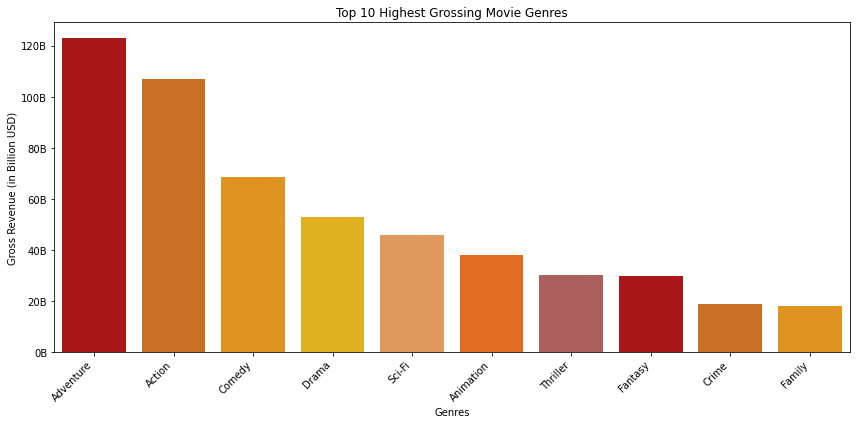

In [26]:
import matplotlib.ticker as ticker

# Plot the graph for the top 10 genres by revenues
plt.figure(figsize=(12, 6))
sns.barplot(y='adjusted_gross', x='genres', data=top10_genres_revenues, palette=red_orange_palette)
plt.title('Top 10 Highest Grossing Movie Genres')
plt.ylabel('Gross Revenue (in Billion USD)')
plt.xlabel('Genres')

# Format y-axis to show billions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B')
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Adventure films jump to the top spot with over USD 120B grossed to date

- Action (USD 107B) and Comedy (USD 69B) films follow closely behind 

#### Objective 2: Find the Top 10 Highest Grossing Movie directors

In [27]:
# Group by 'director_name' and calculate the average rating
top_directors_revenues = movies_consolidated_df_2.groupby('director_name')['worldwide_gross'].sum().reset_index()

# Sort the directors by average rating in descending order
top_directors_revenues = top_directors_revenues.sort_values(by='worldwide_gross', ascending=False).head(10)
top_directors_revenues

,director_name,worldwide_gross
61,Anthony Russo,3.902606e+09
173,Christopher Nolan,3.086180e+09
398,James Wan,2.983618e+09
751,Peter Jackson,2.922948e+09
519,Joss Whedon,2.920950e+09
640,Michael Bay,2.911998e+09
763,Pierre Coffin,2.679018e+09
315,Francis Lawrence,2.543192e+09
1020,Zack Snyder,2.420920e+09
133,Bryan Singer,2.383073e+09


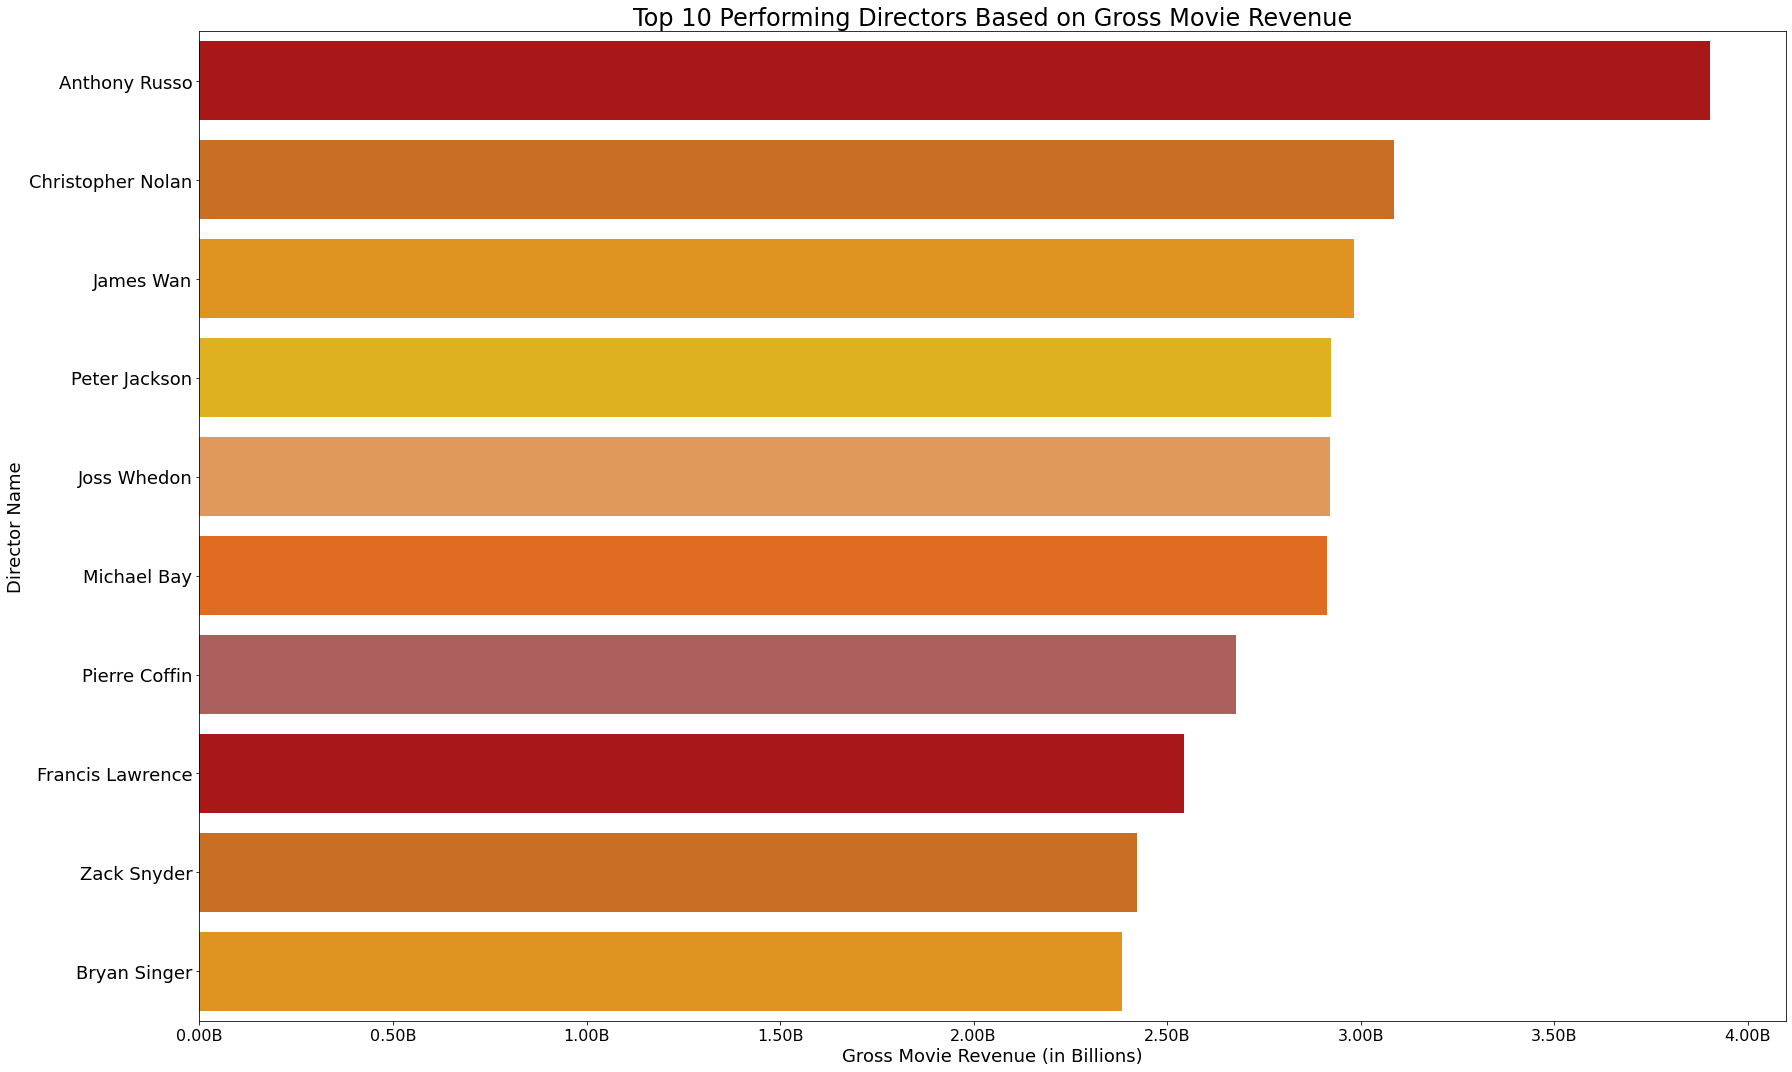

In [28]:
# Plot
fig, ax = plt.subplots(figsize=(25, 15))
sns.barplot(data=top_directors_revenues, y='director_name', x='worldwide_gross', palette=red_orange_palette, ax=ax)

ax.set_title('Top 10 Performing Directors Based on Gross Movie Revenue', fontsize=24)
ax.set_xlabel('Gross Movie Revenue (in Billions)', fontsize=18)
ax.set_ylabel('Director Name', fontsize=18)

# Format x-axis as billions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e9:.02f}B')
ax.xaxis.set_major_formatter(formatter)

# 🔥 Adjust tick label font size
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=18)  # y-axis = director names

# Optional: add space if labels are long
plt.tight_layout()
plt.show()

- The following Directors are the top 3 highest grossing movie directors (their movies make the most money):
    - Anthony Russo, 
    - Christopher Nolan
    - James Wan 


#### Objective 3: Find the Top 10 Highest Grossing Movie Markets

In [29]:
# Mapping regions
region_mapping = {
    'US': 'United States',
    'IN': 'India',
    'CA': 'Canada',
    'GB': 'United Kingdom',
    'FR': 'France',
    'SE': 'Sweden',
    'AR': 'Argentina',
    'ES': 'Spain',
    'XWW': 'Worldwide',
    'Unknown': 'Unknown'
}
# Apply the mapping to the 'region' column
movies_consolidated_df_2['region'] = movies_consolidated_df_2['region'].map(region_mapping).fillna('Unknown')

# Group movie revenue by region/market
region_revenues = movies_consolidated_df_2[['region', 'domestic_gross', 'worldwide_gross']].groupby('region').sum().reset_index()
top10_region_revenues = region_revenues.sort_values(by='worldwide_gross', ascending=False).head(10)
top10_region_revenues = top10_region_revenues[top10_region_revenues['region'] != 'Unknown'].copy()
top10_region_revenues

,region,domestic_gross,worldwide_gross
7,United States,5.088555e+09,1.226588e+10
4,Spain,2.748593e+09,6.900648e+09
0,Argentina,2.766465e+09,6.858552e+09
2,France,2.077801e+09,5.750807e+09
5,Sweden,1.716760e+09,5.095270e+09
1,Canada,2.199481e+09,5.018960e+09
9,Worldwide,2.710377e+08,7.672214e+08
3,India,1.286843e+08,4.375214e+08
6,United Kingdom,1.637412e+08,4.162659e+08


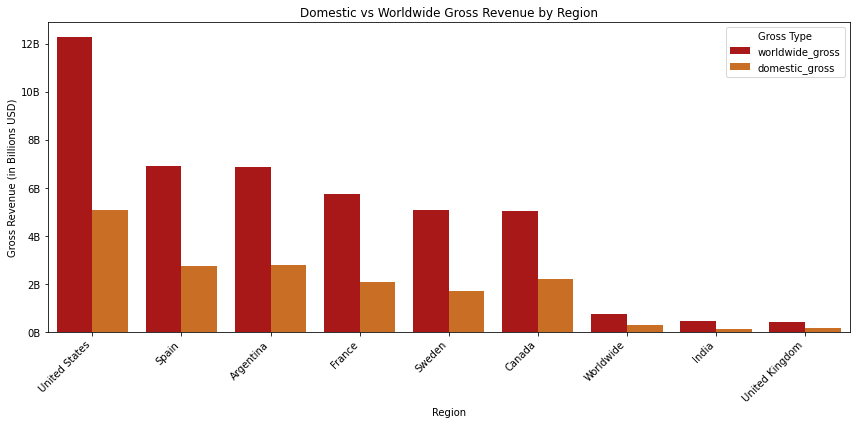

In [30]:
# Combining both Domestic and Worldwide data

# Melt into long format
melted = top10_region_revenues.melt(
    id_vars='region',
    value_vars=['worldwide_gross','domestic_gross'],
    var_name='gross_type',
    value_name='gross_value'
)


# Plot grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x='region', y='gross_value', hue='gross_type', palette=red_orange_palette)

plt.title('Domestic vs Worldwide Gross Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Gross Revenue (in Billions USD)')
plt.xticks(rotation=45, ha='right')

# Format y-axis to show billions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B')
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(title='Gross Type')
plt.tight_layout()
plt.show();


- The top 3 movie markets are found in the US, Spain and Argentina with India and the United Kingdom making up the tail end of this list

- Worldwide Gross Movie Revenues in the US (USD 12B) are nearly 2x* as much as the next two countries (approx. USD 7B)

#### Conclusions

- Action, Adventure and Comedy films are the most profitable genre

- The top 3 highest grossing movie directors are: Anthony Russo, Christopher Nolan, James Wan  

- The most robust movie markets are in the US, Spain and Argentina


### Business Recomendations
- Invest in High-Yield Genres:
  - Prioritize Action, Adventure and Comedy films for greater revenues
- Collaborate with Top Talent:
  - Partner with proven directors who have experience making movies that sell (prioritize profitability).
  - Examples: Anthony Russo, Christopher Nolan, Peter Jackson 
- Expand into Profitable Markets:
  - Create films which cater to audiences in the US, Europe (Spain, France) and Latin America (Argentina)